In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END   # 还导入了起点和终点

In [2]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    finalNumber: int

In [3]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    # 根据状态模式中的 operation 值调用相应的边。注意，状态没有发生任何变化
    if state["operation"] == "+":
        return "addition_operation"   # 在LangGraph中实际返回的是边
    
    elif state["operation"] == "-":
        return "subtraction_operation"



In [ ]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
# 前两个函数都返回了更新后的状态，而第三个函数返回的是边
graph.add_node("router", lambda state:state)   # 不能传入 decide_next_node，而是传入一个输入输出都是相同状态的直通函数

graph.add_edge(START, "router")    # 跟之前不同的初始化方式

graph.add_conditional_edges(
    "router",    # 条件边从路由器节点开始 (source)
    decide_next_node,    # 执行路径 (path)
    # 路径映射，以字典形式呈现
    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

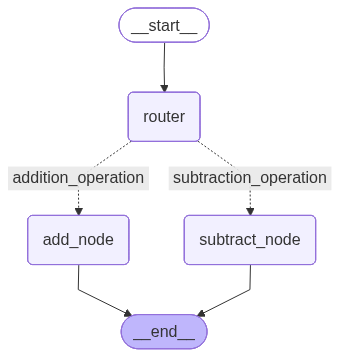

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
# 另一种调用方法
initial_state_1 = AgentState(number1 = 10, operation="-", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


In [7]:
# This way still works!

result = app.invoke({"number1": 10, "operation": "-", "number2": 5})
print(result)

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}
